# Manufacturing Telemetry Demo Data Engineering (MASTER) 

**Live demo**: Bronze → Silver → Gold → (Optional View) → ML scoring.

**Prerequisites (setup):**
1. Create Lakehouse: `lh_manufacturing`
2. Upload `data/telemetry_sample.csv` to Lakehouse **Files** (root) so it is available as `Files/telemetry_sample.csv`.
3. Attach this notebook to the Lakehouse.

**Tables created:**
- `bronze_machine_telemetry_raw`
- `silver_machine_telemetry_clean`
- `gold_machine_kpi_daily`
- `gold_defect_predictions`



---

## ⏸️ 1 Lakehouse setup & Notebook helper

**Click / Do:**

- In Fabric workspace: create/open Lakehouse `lh_manufacturing`.
- Upload the file `telemetry_sample.csv` to Lakehouse → Files.
- Open this notebook and click ‘Attach to Lakehouse’ → select `lh_manufacturing`.
- Run the cell to ensure the notebook runs consistently across environments, standardizes Spark functions, and guarantees readable visualizations.

---


In [1]:
# Common imports & helpers (Fabric notebooks)
from pyspark.sql import functions as F
from pyspark.sql import types as T
import matplotlib.pyplot as plt

# display() exists in Fabric; fallback if running elsewhere
try:
    display
except NameError:
    def display(x):
        try:
            x.show(20, truncate=False)
        except Exception:
            print(x)

plt.rcParams['figure.figsize'] = (10,4)


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 3, Finished, Available, Finished, False)


---

## ⏸️ 2 Load and preview the telemetry file


**Click / Do:**

- Run the next cell to load and preview the telemetry file.

---


In [2]:
telemetry_path = 'Files/telemetry_sample.csv'

df_raw = (spark.read
          .option('header', True)
          .option('inferSchema', True)
          .csv(telemetry_path))

print('Rows:', df_raw.count())
display(df_raw.limit(10))


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 6, Finished, Available, Finished, False)

Rows: 1200


SynapseWidget(Synapse.DataFrame, 9e7a187d-9a8d-45cb-84d9-4ff882b3c9ca)


---

## ⏸️ 3 Render the quick histograms

**Click / Do:**

- Run the next cell to render the quick histograms.

---


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 7, Finished, Available, Finished, False)

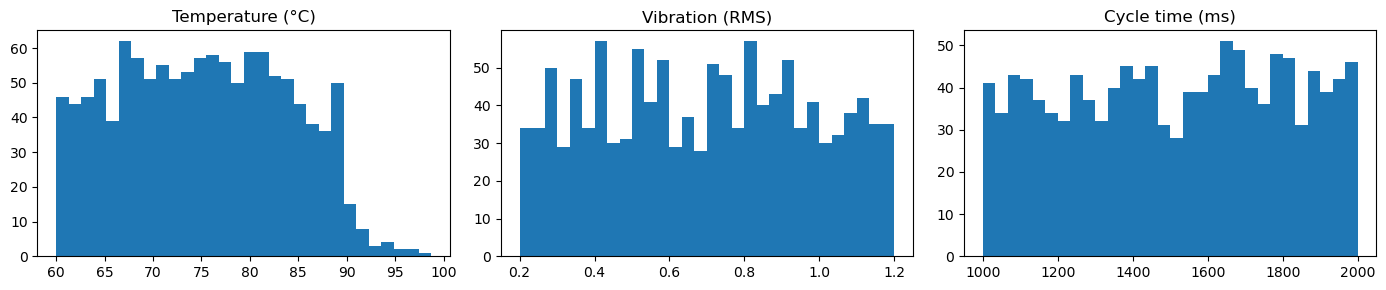

In [3]:
pdf = df_raw.select('tempC','vibration','cycleTime').toPandas()

fig, ax = plt.subplots(1,3, figsize=(14,3))
ax[0].hist(pdf['tempC'], bins=30)
ax[0].set_title('Temperature (°C)')
ax[1].hist(pdf['vibration'], bins=30)
ax[1].set_title('Vibration (RMS)')
ax[2].hist(pdf['cycleTime'], bins=30)
ax[2].set_title('Cycle time (ms)')
plt.tight_layout();
plt.show()



---

## ⏸️ 4 Create the Bronze Delta table

**Click / Do:**

- Run the next cell to create the Bronze Delta table.
- After it finishes: switch to the Lakehouse tab, refresh Tables, and show the new Bronze table.

---


In [4]:
(df_raw
 .write
 .mode('overwrite')
 .format('delta')
 .saveAsTable('bronze_machine_telemetry_raw'))

print('✅ Wrote table: bronze_machine_telemetry_raw')


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 9, Finished, Available, Finished, False)

✅ Wrote table: bronze_machine_telemetry_raw



---

## ⏸️ 5 Transform Bronze → Silver

**Click / Do:**

- Run the next cell to transform Bronze → Silver.

---


In [5]:
df_bronze = spark.table('bronze_machine_telemetry_raw')

df_silver = (df_bronze
    .withColumn('timestamp', F.to_timestamp('timestamp'))
    .withColumn('date', F.to_date('timestamp'))
    .withColumn('reworkCode', F.when(F.col('reworkCode').isNull(), F.lit('')).otherwise(F.col('reworkCode')))
    .withColumn('isDefect', F.when(F.col('qcResult') == F.lit('FAIL'), F.lit(1)).otherwise(F.lit(0)))
)

display(df_silver.orderBy(F.col('timestamp')).limit(10))


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 10, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, b07fe3d3-6824-4f07-a273-7c2975f87677)


---

## ⏸️ 6 Persist Silver table

**Click / Do:**

- Run the next cell to write `silver_machine_telemetry_clean`.
- Refresh Lakehouse Tables and show the Silver table.

---


In [6]:
(df_silver
 .write
 .mode('overwrite')
 .format('delta')
 .saveAsTable('silver_machine_telemetry_clean'))

print('✅ Wrote table: silver_machine_telemetry_clean')


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 11, Finished, Available, Finished, False)

✅ Wrote table: silver_machine_telemetry_clean



---

## ⏸️ 7 Defect rate by machine

**Click / Do:**

- Run the next cell to plot defect rate by machine.

---


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 12, Finished, Available, Finished, False)

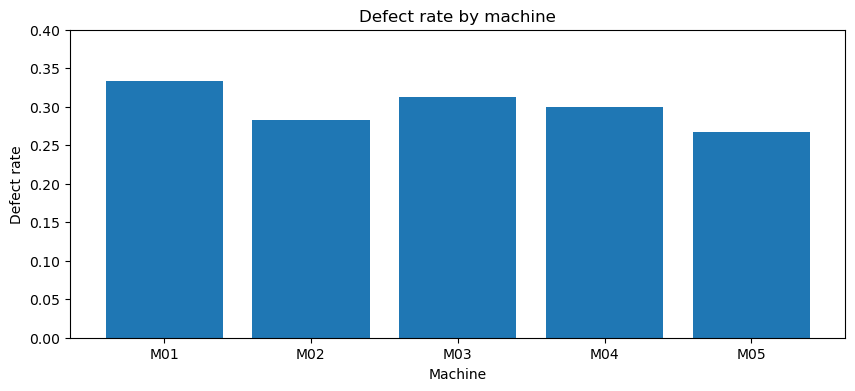

In [7]:
agg = (df_silver.groupBy('machineId')
       .agg(F.count('*').alias('events'), F.sum('isDefect').alias('defects'))
       .withColumn('defect_rate', F.col('defects')/F.col('events'))
)

pdf = agg.orderBy('machineId').toPandas()
plt.bar(pdf['machineId'], pdf['defect_rate'])
plt.title('Defect rate by machine')
plt.ylabel('Defect rate')
plt.xlabel('Machine')
plt.ylim(0, max(0.05, float(pdf['defect_rate'].max())*1.2))
plt.show()



---

## ⏸️ 8 Create Gold KPIs

**Click / Do:**

- Run the next cell to build Gold KPIs.

---


In [8]:
df_gold = (df_silver
    .groupBy('machineId','date')
    .agg(
        F.avg('tempC').alias('avg_temp'),
        F.avg('vibration').alias('avg_vibration'),
        F.avg('cycleTime').alias('avg_cycle_time'),
        F.count('*').alias('events'),
        F.sum('isDefect').alias('total_defects')
    )
    .withColumn('defect_rate', F.col('total_defects')/F.col('events'))
)

display(df_gold.orderBy('date','machineId').limit(20))


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 14, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 4f77ba18-1fc0-463f-b294-4aa6788bd3b7)


---

## ⏸️ 9 Create persist Gold KPIs table

Note: this is a materialized view equivalent

**Click / Do:**

- Run the next cell to write `gold_machine_kpi_daily`.
- Refresh Lakehouse Tables and show the Gold table.

---


In [9]:
(df_gold
 .write
 .mode('overwrite')
 .format('delta')
 .saveAsTable('gold_machine_kpi_daily'))

print('✅ Materialized table created: gold_machine_kpi_daily')


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 15, Finished, Available, Finished, False)

✅ Materialized table created: gold_machine_kpi_daily



---

## ⏸️ 10 Daily defect rate trends

**Click / Do:**

- Run the next cell to plot daily defect rate trends.

---


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 16, Finished, Available, Finished, False)

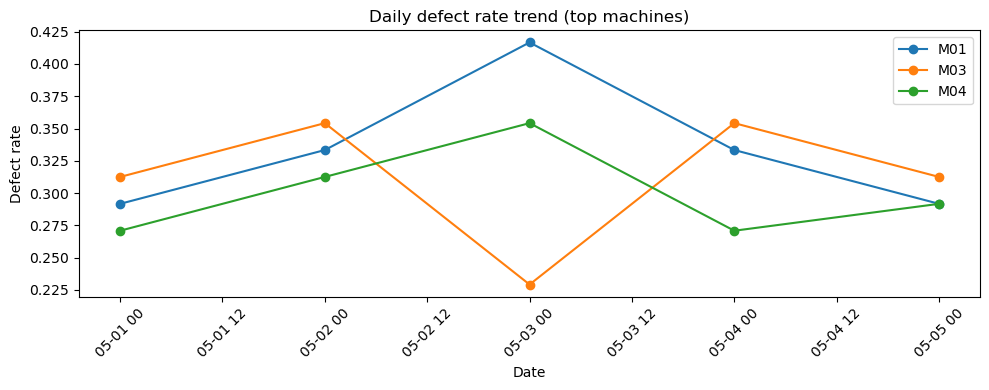

In [10]:
pdf = df_gold.toPandas()

rank = (pdf.groupby('machineId')['defect_rate'].mean().sort_values(ascending=False))
top = list(rank.head(3).index)

for m in top:
    s = pdf[pdf['machineId']==m].sort_values('date')
    plt.plot(s['date'], s['defect_rate'], marker='o', label=m)

plt.title('Daily defect rate trend (top machines)')
plt.ylabel('Defect rate')
plt.xlabel('Date')
plt.legend();
plt.xticks(rotation=45)
plt.tight_layout();
plt.show()



---

## ⏸️ 11 Create View with SQL Endpoint

**Click / Do:**

- Open Lakehouse → SQL endpoint.
- Create a new query and run the SQL shown in the next cell.
- After execution, return here to continue the demo.

---


In [11]:
sql_mlv = '''CREATE VIEW mlv_machine_kpi_fast AS
SELECT
  machineId,
  [date],
  avg_temp,
  avg_vibration,
  avg_cycle_time,
  total_defects,
  defect_rate
FROM gold_machine_kpi_daily;
'''
print(sql_mlv)


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 18, Finished, Available, Finished, False)

CREATE VIEW mlv_machine_kpi_fast AS
SELECT
  machineId,
  [date],
  avg_temp,
  avg_vibration,
  avg_cycle_time,
  total_defects,
  defect_rate
FROM gold_machine_kpi_daily;




---

## ⏸️ 12 Monitoring Hub / Spark UI

**Click / Do:**

- (Optional) Navigate: Workspace → Monitoring Hub.
- Filter to Notebook runs and open the latest run.
- Point out how you’d drill into Spark UI and logs.

---



---

## ⏸️ 13 Train and evaluate a baseline model in Spark ML

🏭 Predictive Quality / Predictive Maintenance use case

Input → machine telemetry

Output → defect probability

Question: “Given current machine behavior, how likely is a defect?”

**Click / Do:**

- Run the next cell to train and evaluate a baseline model in Spark ML.

---


In [12]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

ml = df_silver.select('machineId','stationId','timestamp','tempC','vibration','cycleTime','isDefect')

assembler = VectorAssembler(inputCols=['tempC','vibration','cycleTime'], outputCol='features')
ml_vec = assembler.transform(ml).select('machineId','stationId','timestamp','features', F.col('isDefect').alias('label'))

train, test = ml_vec.randomSplit([0.8, 0.2], seed=42)

lr = LogisticRegression(featuresCol='features', labelCol='label', maxIter=50)
model = lr.fit(train)

pred_test = model.transform(test)

eval = BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC')
auc = eval.evaluate(pred_test)
print(f'AUC: {auc:.3f}')


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 19, Finished, Available, Finished, False)

AUC: 0.752



---

## ⏸️ 14 Visualize directional feature impact

**Click / Do:**

- Run the next cell to visualize directional feature impact.

---


StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 20, Finished, Available, Finished, False)

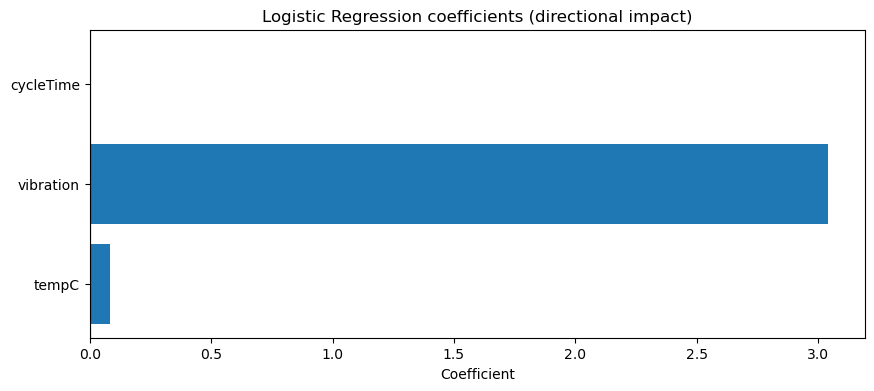

In [13]:
coefs = model.coefficients.toArray().tolist()
features = ['tempC','vibration','cycleTime']

plt.barh(features, coefs)
plt.title('Logistic Regression coefficients (directional impact)')
plt.xlabel('Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()



---

## ⏸️ 15 Create predictions table

**Click / Do:**

- Run the next cell to score and write `gold_defect_predictions`.
- Refresh Lakehouse Tables and show the predictions table.

---


In [14]:
from pyspark.ml.functions import vector_to_array

pred_full = model.transform(ml_vec)

scored = (
    pred_full
    .withColumn("probability_array", vector_to_array("probability"))
    .select(
        "machineId",
        "stationId",
        "timestamp",
        F.col("probability_array")[1].alias("defect_probability"),
        F.col("prediction").cast("int").alias("defect_prediction")
    )
)

display(scored.orderBy(F.col("defect_probability").desc()).limit(20))

(scored
 .write
 .mode("overwrite")
 .format("delta")
 .saveAsTable("gold_defect_predictions"))

print("✅ Wrote table: gold_defect_predictions")

StatementMeta(, c7c0a26d-7935-422f-bcb1-b6b382c182ea, 22, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 4752e81b-4adb-4412-afc3-a15eed080354)

✅ Wrote table: gold_defect_predictions
